# Dataset Overview, Coverage & Filtering

Combined notebook for dataset exploration, overlap analysis, and filtered dataset creation.

**Sections:**
1. Pre-training dataset overview (LINCS, PCQM)
2. Pre-training data: cell & literature embeddings (RxRx3, BBBC047, Literature)
3. Data coverage: pre-training vs ADMET test set overlap
4. DTI filtered dataset creation
5. BBBC047 / LargeMix overlap analysis

---
## 1. Pre-training Dataset Overview

In [1]:
import pandas as pd

### LINCS 1000

In [2]:
csv_path = "/home/shpark/prj-molrepr/graphium/data/graphium/neurips2023/large-dataset/LINCS_L1000_VCAP_0-2_th2.csv"
df = pd.read_csv(csv_path)
df.head()

,Unnamed: 0,full_id,pert_id,cell_iname,SMILES,inchi_key,compound_aliases,geneID-10007,geneID-1001,geneID-10013,...,geneID-9918,geneID-9924,geneID-9926,geneID-9928,geneID-993,geneID-994,geneID-9943,geneID-9961,geneID-998,geneID-9988
0,0,CPC004_VCAP_6H:BRD-K63945320-001-03-2:10,BRD-K63945320,VCAP,CC(C)CC(=O)O[C@@H]1[C@H](OC(=O)C)c2c(OC1(C)C)c...,ALKTVPFKDYZFGA-WOJBJXKFSA-N,NaN,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,1,CPC004_VCAP_6H:BRD-K56558538-003-02-8:10,BRD-K56558538,VCAP,Nc1c(Br)cc(Br)cc1CN[C@H]1CC[C@H](O)CC1,JBDGDEWWOUBZPM-XYPYZODXSA-N,NaN,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,2,CPC014_VCAP_24H:BRD-K02421873-001-05-4:10,BRD-K02421873,VCAP,[O-][N+](=O)c1ccc(o1)C(=O)OCc2nnc(o2)c3ccccc3,NENLILZNTFFZKS-UHFFFAOYSA-N,NaN,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,3,CPC004_VCAP_6H:BRD-A09467419-003-14-1:10,BRD-A09467419,VCAP,CCN(CCCCOC(=O)c1ccc(OC)c(OC)c1)C(C)Cc1ccc(OC)cc1,VYVKHNNGDFVQGA-UHFFFAOYSA-N,NaN,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4,4,CPC004_VCAP_6H:BRD-A00546892-001-01-8:10,BRD-A00546892,VCAP,OC(CCN1CCCCC1)(C1CC2CC1C=C2)c1ccccc1,YSXKPIUOCJLQIE-UHFFFAOYSA-N,NaN,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [3]:
print(f"Unique SMILES: {df['SMILES'].nunique()}")
print(f"Total molecules: {len(df)}")

# Count the number of molecules with each unique SMILES
smiles_counts = df['SMILES'].value_counts()
print(f"Number of molecules with each unique SMILES:")
print(smiles_counts)

Unique SMILES: 15193
Total molecules: 15220
Number of molecules with each unique SMILES:
SMILES
restricted                                                                        14
NC(=N)NN=Cc1c(Cl)cccc1Cl                                                           2
CC(C)c1c(C(=O)Nc2ccccc2)c(c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(O)=O)-c1ccccc1            2
CC(=CCO)C=CC=C(C)C=CC1=C(C)CCCC1(C)C                                               2
CCOC(=O)C1=C(NC(=C(C1C2=CC=CC=C2Cl)C(=O)OC)C)COCCN                                 2
                                                                                  ..
CC(C)NC(=O)N1[C@H](CO)[C@@H]([C@@H]1C#N)c1ccc(cc1)-c1ccc(F)cc1                     1
CN(C)C(=O)c1cccc(c1)-c1ccc(cc1)[C@H]1[C@@H]2CNC[C@H]1N2Cc1ccc2OCOc2c1              1
Cc1ccc(cc1)S(=O)(=O)N[C@H]1CC[C@@H](CCNC(=O)c2ccccc2F)O[C@H]1CO                    1
C[C@@H](CO)N1C[C@H](C)[C@@H](CN(C)C(=O)NC2CCCCC2)Oc3ccc(NC(=O)CCCN(C)C)cc3C1=O     1
COCC(=O)Nc1ccc2O[C@@H]3[C@@H](C[C@H](CC(=O)NCc4ccccc4F

### PCQM

In [4]:
import pyarrow.parquet as pq

parquet_file = "/home/shpark/prj-molrepr/graphium/data/graphium/neurips2023/large-dataset/PCQM4M_G25_N4.parquet"
schema = pq.read_schema(parquet_file)

print(schema.names)

['ordered_cxsmiles_3d', 'ordered_smiles', 'graph_alpha_homo', 'graph_alpha_gap', 'graph_beta_homo', 'graph_beta_gap', 'graph_energy_total', 'graph_principal_length_a', 'graph_principal_length_b', 'graph_principal_length_c', 'graph_inertia_mass_a', 'graph_inertia_mass_b', 'graph_inertia_mass_c', 'graph_inertia_valence_a', 'graph_inertia_valence_b', 'graph_inertia_valence_c', 'graph_inertia_charges_mulliken_a', 'graph_inertia_charges_mullkien_b', 'graph_inertia_charges_mulliken_c', 'graph_inertia_charges_lowdin_a', 'graph_inertia_charges_lowdin_b', 'graph_inertia_charges_lowdin_c', 'graph_spherocity', 'graph_plane_best_fit', 'graph_tddft_alpha_gap', 'graph_tddft_energy_beta_gap', 'graph_tddft_energy_total', 'node_charges_mulliken', 'node_charges_lowdin', 'node_tddft_charges_mulliken', 'node_tddft_charges_lowdin']


In [5]:
for name in schema.names:
	if "homo" in name or "lumo" in name:
		print(name)


graph_alpha_homo
graph_beta_homo


---
## 2. Pre-training Data: Cell & Literature Embeddings

In [6]:
import pandas as pd
import numpy as np
import torch
import zipfile, io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 5)
plt.rcParams["figure.dpi"] = 120

### 1. Load datasets

In [7]:
# --- RxRx3 ---
rxrx3_df = pd.read_csv("../data/rxrx3/rxrx3_smiles_embeddings.csv")
rxrx3_feat_cols = [c for c in rxrx3_df.columns if c.startswith("feature_")]
rxrx3_emb = rxrx3_df[rxrx3_feat_cols].values
print(f"RxRx3:      {rxrx3_emb.shape[0]:>10,} samples x {rxrx3_emb.shape[1]} dims")

# --- BBBC047 ---
bbbc_df = pd.read_csv("../../data/bbbc047/bbbc047_smiles_embeddings.csv")
bbbc_feat_cols = [c for c in bbbc_df.columns if c.startswith("feature_")]
bbbc_emb = bbbc_df[bbbc_feat_cols].values
print(f"BBBC047:    {bbbc_emb.shape[0]:>10,} samples x {bbbc_emb.shape[1]} dims")

# --- Literature ---
with zipfile.ZipFile("../data/literature/literature_embeddings.zip") as z:
    with z.open("embeddings.pt") as f:
        lit_tensors = torch.load(io.BytesIO(f.read()), map_location="cpu")
lit_emb = torch.cat(lit_tensors, dim=0).numpy()  # (N, 768)
print(f"Literature: {lit_emb.shape[0]:>10,} samples x {lit_emb.shape[1]} dims")

RxRx3:          63,405 samples x 384 dims
BBBC047:       109,645 samples x 672 dims
Literature:    160,560 samples x 768 dims


### 2. Summary statistics

In [8]:
datasets = {"RxRx3": rxrx3_emb, "BBBC047": bbbc_emb, "Literature": lit_emb}

rows = []
for name, emb in datasets.items():
    norms = np.linalg.norm(emb, axis=1)
    rows.append({
        "Dataset": name,
        "Samples": f"{emb.shape[0]:,}",
        "Dims": emb.shape[1],
        "Global Mean": f"{emb.mean():.4f}",
        "Global Std": f"{emb.std():.4f}",
        "Min": f"{emb.min():.4f}",
        "Max": f"{emb.max():.4f}",
        "L2 Norm (mean)": f"{norms.mean():.2f}",
        "L2 Norm (std)": f"{norms.std():.2f}",
        "% Zero": f"{(emb == 0).mean() * 100:.1f}%",
    })

summary = pd.DataFrame(rows).set_index("Dataset")
summary

,Samples,Dims,Global Mean,Global Std,Min,Max,L2 Norm (mean),L2 Norm (std),% Zero
Dataset,,,,,,,,,
RxRx3,"63,405",384,-0.0369,0.2748,-3.9312,1.8324,5.42,0.31,0.0%
BBBC047,"109,645",672,1.2556,0.7234,-0.2735,7.2445,37.56,0.71,0.0%
Literature,"160,560",768,-0.0190,0.4709,-2.9327,2.4404,13.06,0.37,0.0%


### 3. Embedding value distributions

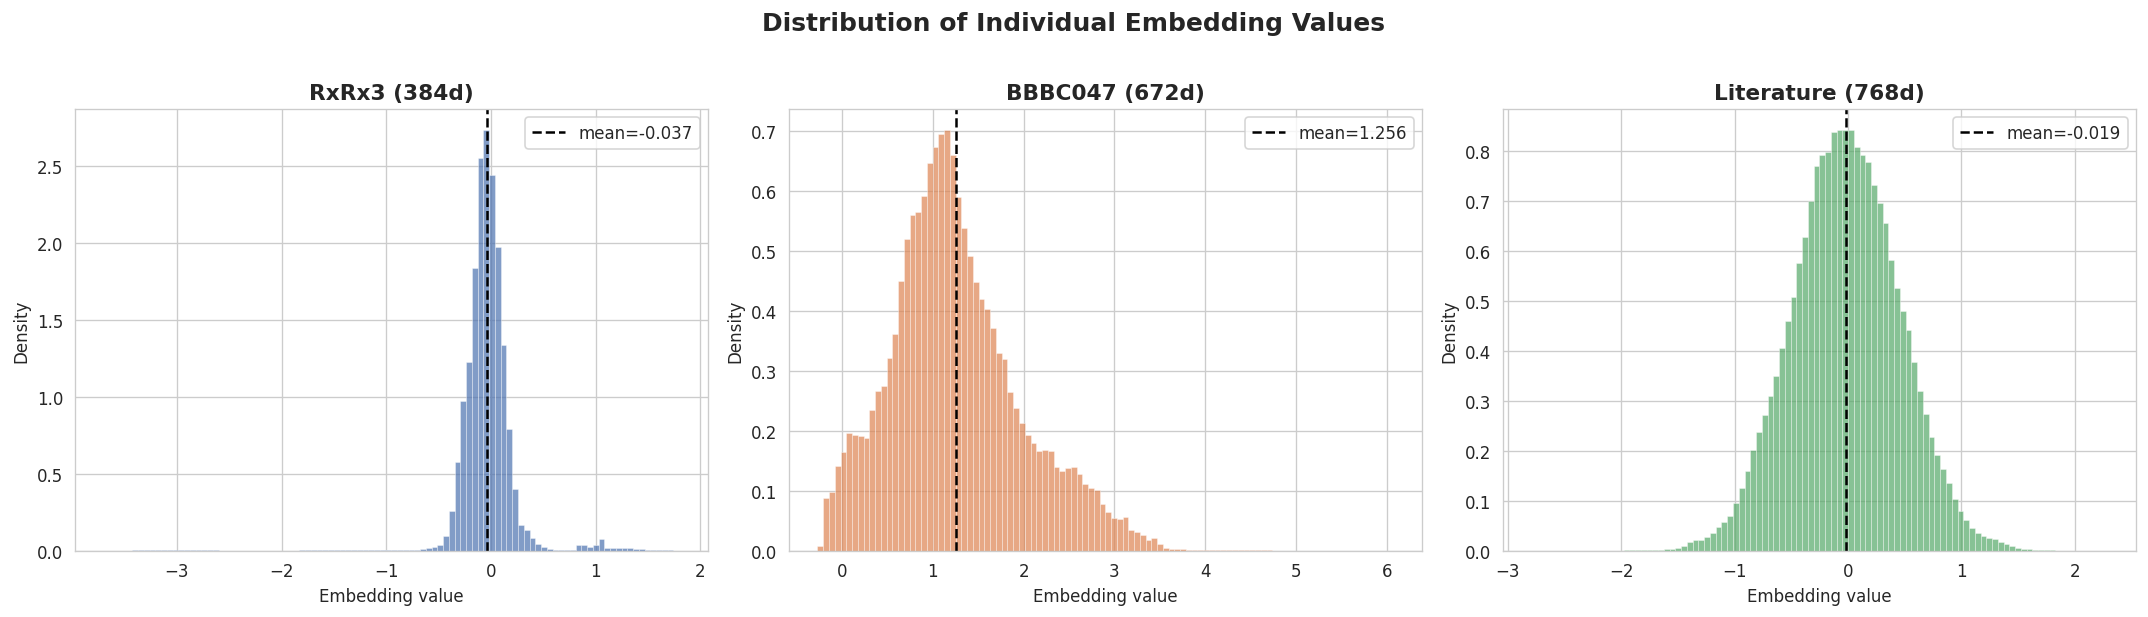

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, (name, emb), color in zip(axes, datasets.items(), colors):
    # Flatten a random subset for plotting speed
    rng = np.random.default_rng(42)
    flat = emb[rng.choice(len(emb), min(5000, len(emb)), replace=False)].ravel()
    ax.hist(flat, bins=100, color=color, alpha=0.7, edgecolor="white", linewidth=0.3, density=True)
    ax.axvline(flat.mean(), color="k", ls="--", lw=1.5, label=f"mean={flat.mean():.3f}")
    ax.set_title(f"{name} ({emb.shape[1]}d)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Embedding value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=10)

fig.suptitle("Distribution of Individual Embedding Values", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4. L2 norm distributions

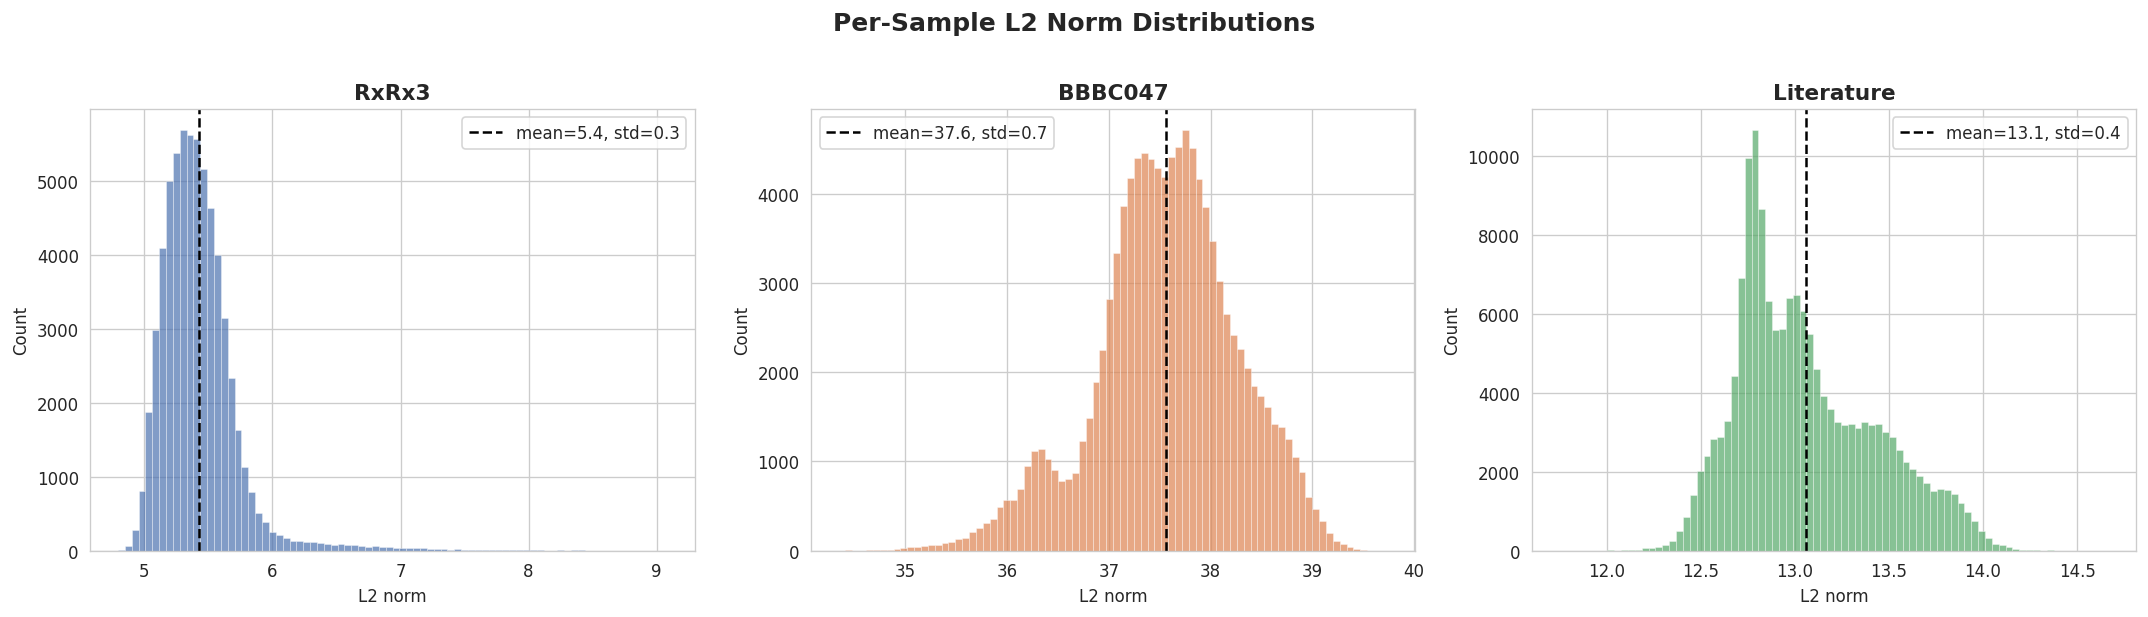

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, emb), color in zip(axes, datasets.items(), colors):
    norms = np.linalg.norm(emb, axis=1)
    ax.hist(norms, bins=80, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.axvline(norms.mean(), color="k", ls="--", lw=1.5,
               label=f"mean={norms.mean():.1f}, std={norms.std():.1f}")
    ax.set_title(f"{name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("L2 norm")
    ax.set_ylabel("Count")
    ax.legend(fontsize=10)

fig.suptitle("Per-Sample L2 Norm Distributions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5. Per-dimension mean and std profiles

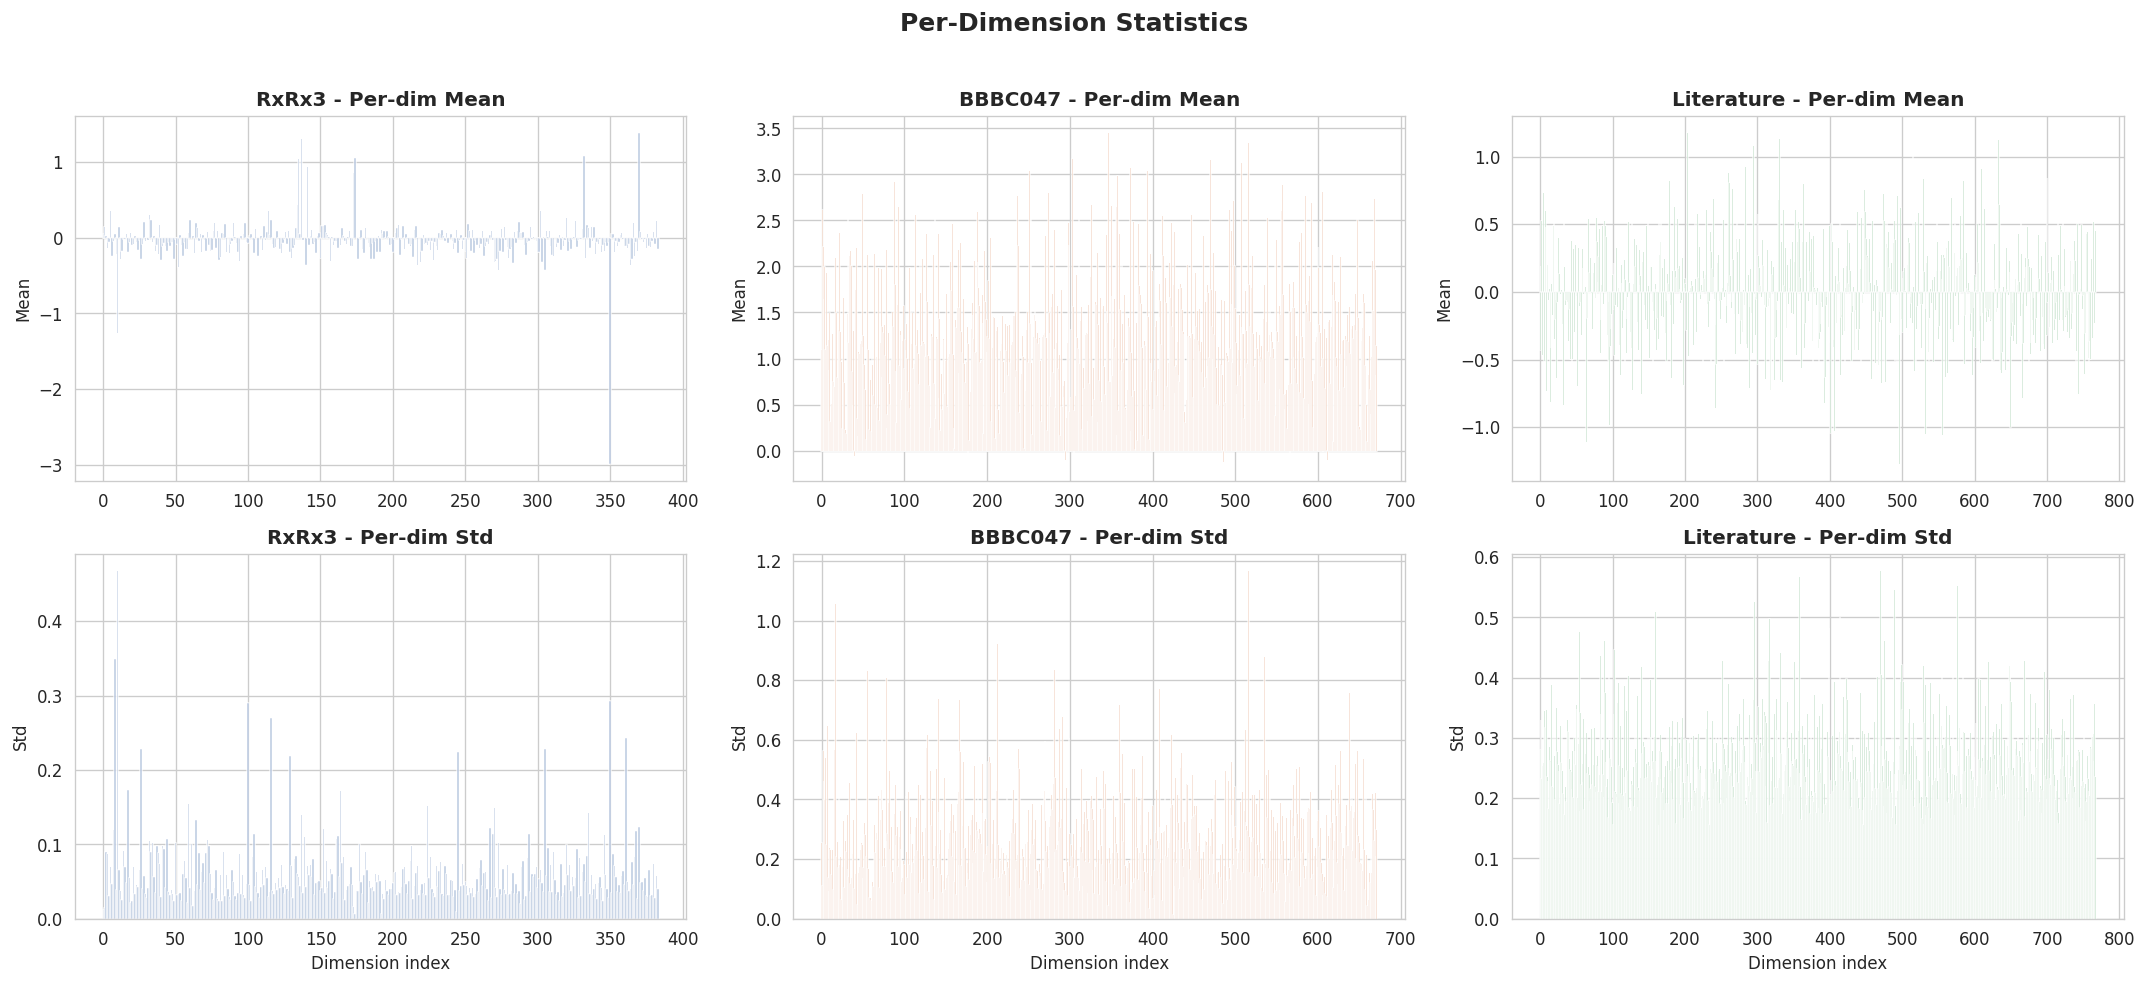

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False)

for col, (name, emb), color in zip(range(3), datasets.items(), colors):
    dim_mean = emb.mean(axis=0)
    dim_std = emb.std(axis=0)
    dims = np.arange(emb.shape[1])

    axes[0, col].bar(dims, dim_mean, color=color, alpha=0.7, width=1.0)
    axes[0, col].set_title(f"{name} - Per-dim Mean", fontsize=12, fontweight="bold")
    axes[0, col].set_ylabel("Mean")

    axes[1, col].bar(dims, dim_std, color=color, alpha=0.7, width=1.0)
    axes[1, col].set_title(f"{name} - Per-dim Std", fontsize=12, fontweight="bold")
    axes[1, col].set_xlabel("Dimension index")
    axes[1, col].set_ylabel("Std")

fig.suptitle("Per-Dimension Statistics", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6. PCA projection (2D)

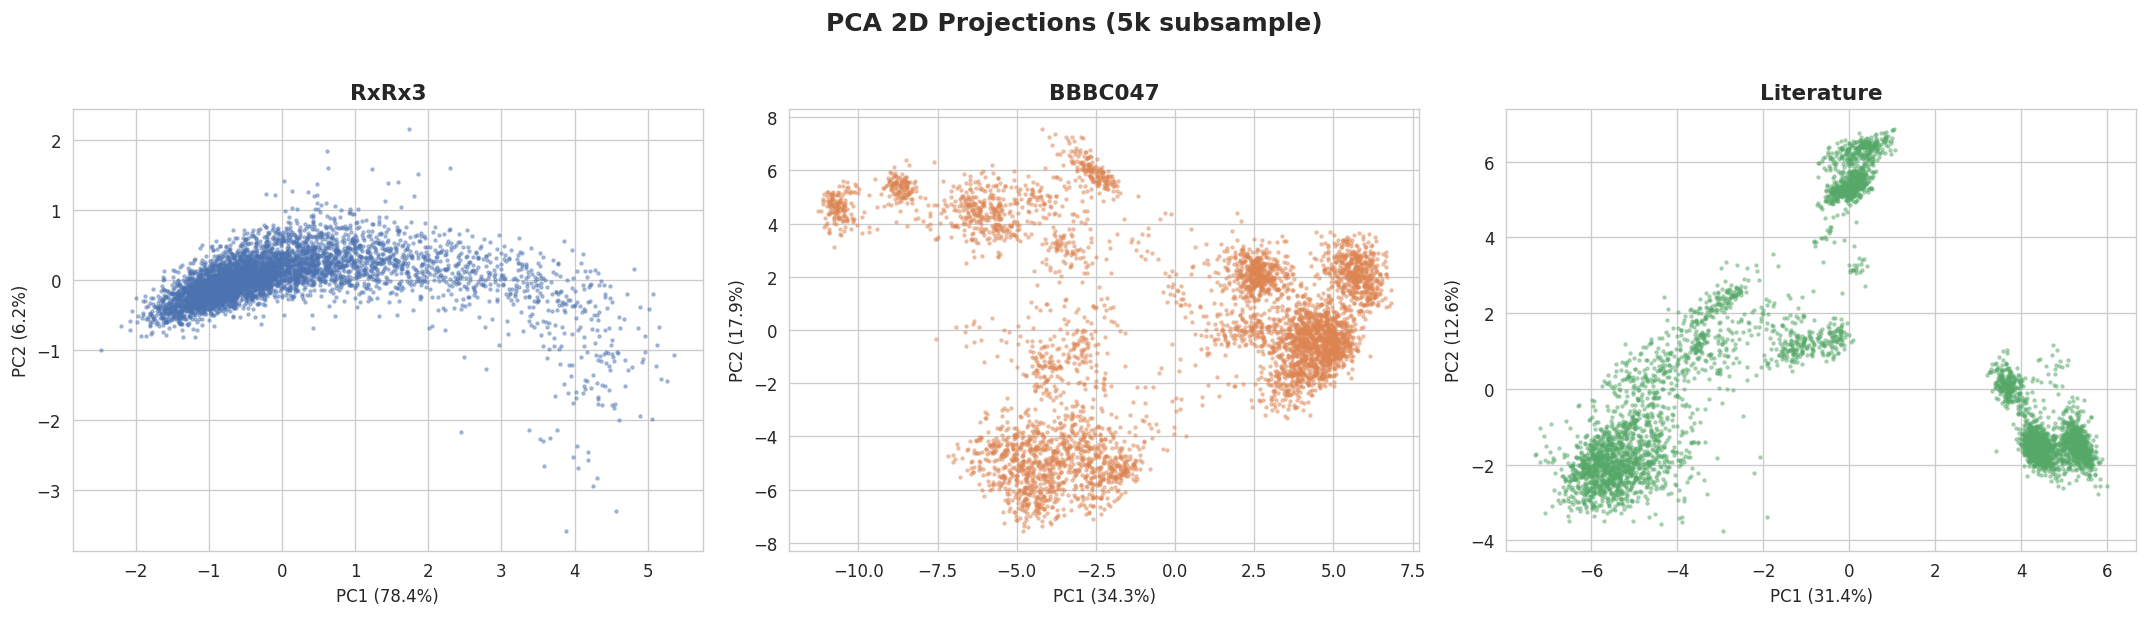

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
rng = np.random.default_rng(42)
n_pca = 5000  # subsample for speed

for ax, (name, emb), color in zip(axes, datasets.items(), colors):
    idx = rng.choice(len(emb), min(n_pca, len(emb)), replace=False)
    sub = emb[idx]
    pca = PCA(n_components=2)
    proj = pca.fit_transform(sub)
    var = pca.explained_variance_ratio_

    ax.scatter(proj[:, 0], proj[:, 1], s=3, alpha=0.4, color=color, rasterized=True)
    ax.set_title(f"{name}", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")

fig.suptitle("PCA 2D Projections (5k subsample)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 7. PCA explained variance (scree plot)

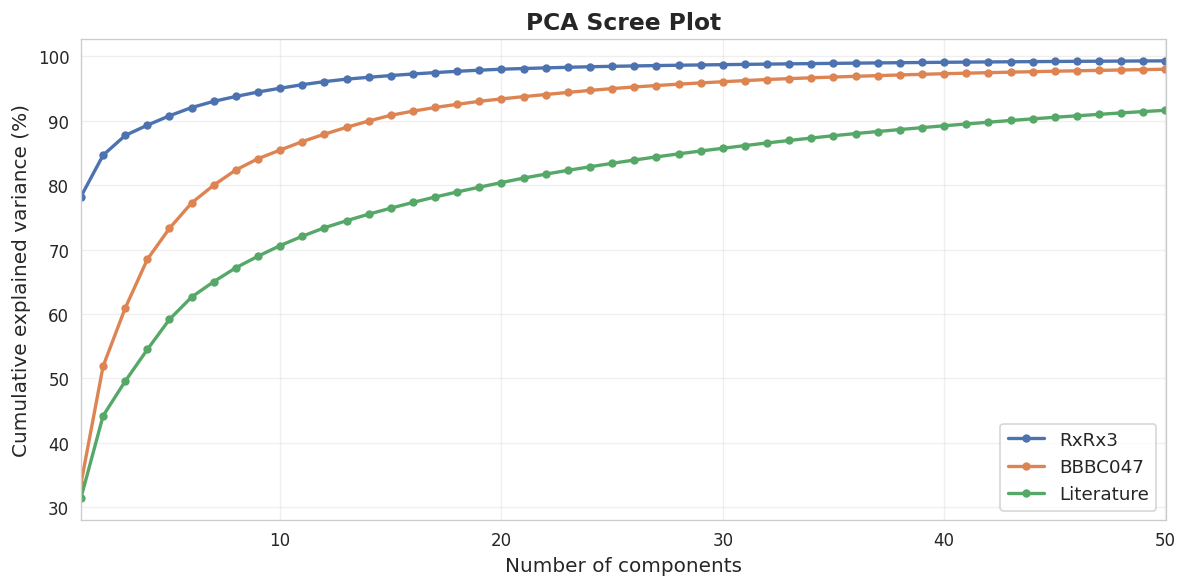

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
n_components = 50

for (name, emb), color in zip(datasets.items(), colors):
    idx = rng.choice(len(emb), min(n_pca, len(emb)), replace=False)
    pca = PCA(n_components=min(n_components, emb.shape[1]))
    pca.fit(emb[idx])
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(range(1, len(cumvar) + 1), cumvar, "o-", color=color, ms=4, lw=2, label=name)

ax.set_xlabel("Number of components", fontsize=12)
ax.set_ylabel("Cumulative explained variance (%)", fontsize=12)
ax.set_title("PCA Scree Plot", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim(1, n_components)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8. Inter-sample cosine similarity distributions

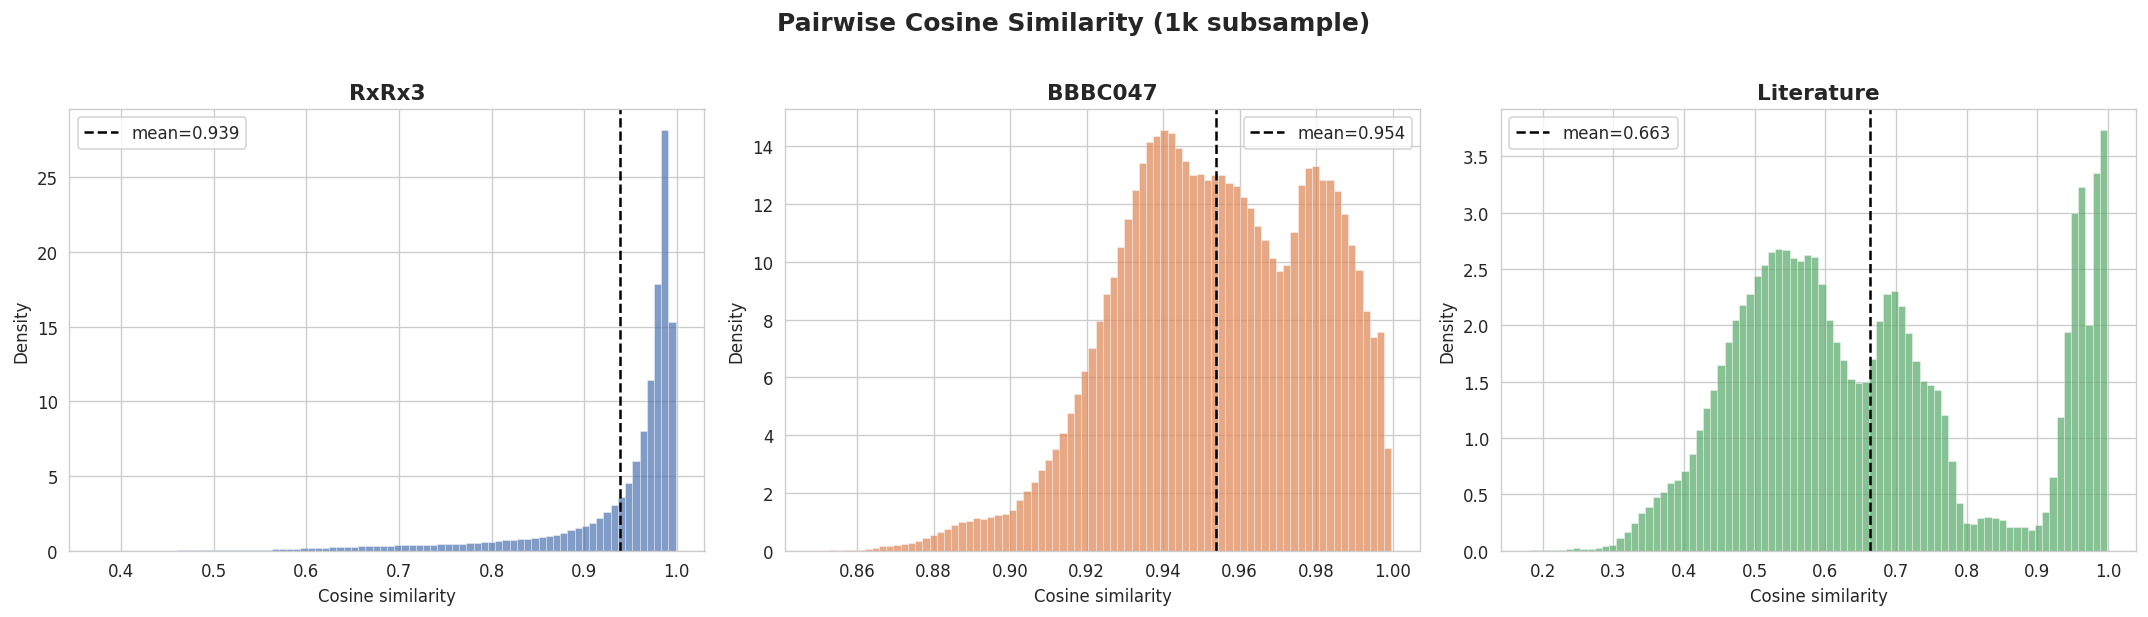

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_cos = 1000  # subsample for speed

for ax, (name, emb), color in zip(axes, datasets.items(), colors):
    idx = rng.choice(len(emb), min(n_cos, len(emb)), replace=False)
    sim = cosine_similarity(emb[idx])
    # Upper triangle only (exclude diagonal)
    triu_idx = np.triu_indices(len(idx), k=1)
    sims = sim[triu_idx]

    ax.hist(sims, bins=80, color=color, alpha=0.7, edgecolor="white", linewidth=0.3, density=True)
    ax.axvline(sims.mean(), color="k", ls="--", lw=1.5,
               label=f"mean={sims.mean():.3f}")
    ax.set_title(f"{name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Density")
    ax.legend(fontsize=10)

fig.suptitle("Pairwise Cosine Similarity (1k subsample)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Data Coverage: Pre-training vs ADMET Test Set Overlap

In [15]:
import pandas as pd
import numpy as np
import pickle
import hashlib
from pathlib import Path
from rdkit import Chem

DATA_DIR = Path('../data')
CACHE_DIR = Path('../datacache/smiles_sets')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def canonicalize(smi):
    """Canonicalize a SMILES string via RDKit. Returns None if invalid."""
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

def load_smiles(path, smiles_col, name):
    """Load unique canonicalized SMILES from a file, with disk caching."""
    path = Path(path)
    if not path.exists():
        print(f'  SKIP {name}: {path} not found')
        return set()

    # Cache key: hash of (file path, file size, file mtime, smiles_col)
    stat = path.stat()
    key_str = f'{path.resolve()}|{stat.st_size}|{stat.st_mtime}|{smiles_col}'
    cache_key = hashlib.md5(key_str.encode()).hexdigest()
    cache_path = CACHE_DIR / f'{name}_{cache_key}.pkl'

    if cache_path.exists():
        canon = pickle.loads(cache_path.read_bytes())
        print(f'  {name}: {len(canon):,} canonical SMILES (cached)')
        return canon

    # Load and canonicalize
    if path.suffix == '.parquet':
        df = pd.read_parquet(path, columns=[smiles_col])
    elif path.suffix == '.gz':
        df = pd.read_csv(path, usecols=[smiles_col])
    else:
        df = pd.read_csv(path, usecols=[smiles_col])
    raw = df[smiles_col].dropna().unique()
    canon = set(filter(None, (canonicalize(s) for s in raw)))
    print(f'  {name}: {len(raw):,} raw -> {len(canon):,} canonical SMILES')

    # Save cache
    cache_path.write_bytes(pickle.dumps(canon))
    return canon

print('Helpers loaded.')

Helpers loaded.


### 1. Load ADMET test sets

In [16]:
from pathlib import Path as _Path
from tdc.benchmark_group import admet_group

TDC_CACHE = str(_Path('~/.cache/graphium/tdc/ADMET_Benchmark/').expanduser())
group = admet_group(path=TDC_CACHE)

# Canonical task ordering (same as results dashboard)
ADMET_TASK_ORDER = [
    # Absorption
    'caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
    'lipophilicity_astrazeneca', 'solubility_aqsoldb',
    # Distribution
    'bbb_martins', 'ppbr_az', 'vdss_lombardo',
    # Metabolism
    'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith',
    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels',
    # Excretion
    'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az',
    # Toxicity
    'ld50_zhu', 'herg', 'ames', 'dili',
]

TASK_CATEGORY = {}
for t in ADMET_TASK_ORDER[:6]:   TASK_CATEGORY[t] = 'Absorption'
for t in ADMET_TASK_ORDER[6:9]:  TASK_CATEGORY[t] = 'Distribution'
for t in ADMET_TASK_ORDER[9:15]: TASK_CATEGORY[t] = 'Metabolism'
for t in ADMET_TASK_ORDER[15:18]: TASK_CATEGORY[t] = 'Excretion'
for t in ADMET_TASK_ORDER[18:]:  TASK_CATEGORY[t] = 'Toxicity'

admet_test_smiles = {}   # task -> set of canonical SMILES (test)
admet_train_smiles = {}  # task -> set of canonical SMILES (train+val)
admet_all_test = set()
admet_all_train = set()

for name in group.dataset_names:
    benchmark = group.get(name)
    # Test set
    test_df = benchmark['test']
    raw_test = test_df['Drug'].dropna().unique()
    canon_test = set(filter(None, (canonicalize(s) for s in raw_test)))
    admet_test_smiles[name] = canon_test
    admet_all_test |= canon_test
    # Train+val set
    train_val_df = benchmark['train_val']
    raw_train = train_val_df['Drug'].dropna().unique()
    canon_train = set(filter(None, (canonicalize(s) for s in raw_train)))
    admet_train_smiles[name] = canon_train
    admet_all_train |= canon_train

print(f'Total unique ADMET test SMILES (union across {len(admet_test_smiles)} tasks): {len(admet_all_test):,}')
print(f'Total unique ADMET train+val SMILES (union): {len(admet_all_train):,}')
print()
print(f'{"Task":<40} {"Category":<15} {"Train+Val":>10} {"Test":>10} {"Total":>10}')
print('=' * 87)
prev_cat = None
for name in ADMET_TASK_ORDER:
    if name not in admet_test_smiles:
        continue
    cat = TASK_CATEGORY[name]
    if prev_cat is not None and cat != prev_cat:
        print('-' * 87)
    prev_cat = cat
    n_train = len(admet_train_smiles[name])
    n_test = len(admet_test_smiles[name])
    print(f'{name:<40} {cat:<15} {n_train:>10,} {n_test:>10,} {n_train + n_test:>10,}')

Found local copy...
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:17:50] WARNING: not removing hydrogen atom without neighbors
[11:1

Total unique ADMET test SMILES (union across 22 tasks): 13,818
Total unique ADMET train+val SMILES (union): 40,229

Task                                     Category         Train+Val       Test      Total
caco2_wang                               Absorption             725        181        906
hia_hou                                  Absorption             461        117        578
pgp_broccatelli                          Absorption             967        245      1,212
bioavailability_ma                       Absorption             512        128        640
lipophilicity_astrazeneca                Absorption           3,360        840      4,200
solubility_aqsoldb                       Absorption           7,985      1,997      9,982
---------------------------------------------------------------------------------------
bbb_martins                              Distribution         1,581        394      1,975
ppbr_az                                  Distribution         1,454        3

### 2. Load pre-training datasets

In [17]:
SMALL = DATA_DIR / 'graphium/neurips2023/small-dataset'
LARGE = DATA_DIR / 'graphium/neurips2023/large-dataset'

pretrain_datasets = {}

# --- ToyMix ---
print('ToyMix:')
pretrain_datasets['QM9'] = load_smiles(SMALL / 'qm9.csv', 'smiles', 'QM9')
pretrain_datasets['Tox21'] = load_smiles(SMALL / 'Tox21-7k-12-labels.csv', 'smiles', 'Tox21')
pretrain_datasets['ZINC12k'] = load_smiles(SMALL / 'ZINC12k.csv', 'smiles', 'ZINC12k')
pretrain_datasets['ToyMix (all)'] = pretrain_datasets['QM9'] | pretrain_datasets['Tox21'] | pretrain_datasets['ZINC12k']
print(f'  ToyMix total unique: {len(pretrain_datasets["ToyMix (all)"]):,}')

# --- LargeMix ---
print('\nLargeMix:')
pretrain_datasets['L1000 VCAP'] = load_smiles(LARGE / 'LINCS_L1000_VCAP_0-2_th2.csv.gz', 'SMILES', 'L1000 VCAP')
pretrain_datasets['L1000 MCF7'] = load_smiles(LARGE / 'LINCS_L1000_MCF7_0-2_th2.csv.gz', 'SMILES', 'L1000 MCF7')
pretrain_datasets['PCBA'] = load_smiles(LARGE / 'PCBA_1328_1564k.parquet', 'SMILES', 'PCBA')
pretrain_datasets['PCQM4M'] = load_smiles(LARGE / 'PCQM4M_G25_N4.parquet', 'ordered_smiles', 'PCQM4M')
pretrain_datasets['LargeMix (all)'] = (pretrain_datasets['L1000 VCAP'] | pretrain_datasets['L1000 MCF7'] |
                                        pretrain_datasets['PCBA'] | pretrain_datasets['PCQM4M'])
print(f'  LargeMix total unique: {len(pretrain_datasets["LargeMix (all)"]):,}')

# --- RxRx3 ---
print('\nRxRx3:')
pretrain_datasets['RxRx3'] = load_smiles(DATA_DIR / 'rxrx3/rxrx3_smiles_embeddings.csv', 'SMILES_nometa', 'RxRx3')

# --- DTI ---
print('\nDTI:')
pretrain_datasets['DTI'] = load_smiles(DATA_DIR / 'dti-processed/dti_esm2_100k.csv', 'SMILES_nometa', 'DTI')

print(f'\nAll pre-training datasets loaded.')

ToyMix:
  QM9: 133,798 canonical SMILES (cached)
  Tox21: 7,831 canonical SMILES (cached)
  ZINC12k: 12,000 canonical SMILES (cached)
  ToyMix total unique: 153,226

LargeMix:
  L1000 VCAP: 15,155 canonical SMILES (cached)
  L1000 MCF7: 11,521 canonical SMILES (cached)
  PCBA: 1,563,664 canonical SMILES (cached)
  PCQM4M: 3,452,168 canonical SMILES (cached)
  LargeMix total unique: 5,017,537

RxRx3:
  RxRx3: 1,672 canonical SMILES (cached)

DTI:
  DTI: 71,773 canonical SMILES (cached)

All pre-training datasets loaded.


### 3. Overlap analysis: pre-training dataset vs ADMET test (union)

In [18]:
# Check each pre-training dataset against the union of all ADMET test SMILES
print(f'ADMET test set (union): {len(admet_all_test):,} unique SMILES\n')
print(f'{"Pre-training Dataset":<25} {"Size":>10} {"Overlap":>10} {"% of Test":>10} {"% of Pretrain":>13}')
print('-' * 72)

datasets_to_check = [
    'QM9', 'Tox21', 'ZINC12k', 'ToyMix (all)',
    'L1000 VCAP', 'L1000 MCF7', 'PCBA', 'PCQM4M', 'LargeMix (all)',
    'RxRx3', 'DTI',
]

overlap_results = {}
for ds_name in datasets_to_check:
    ds = pretrain_datasets[ds_name]
    overlap = ds & admet_all_test
    overlap_results[ds_name] = overlap
    pct_test = 100 * len(overlap) / len(admet_all_test) if admet_all_test else 0
    pct_pretrain = 100 * len(overlap) / len(ds) if ds else 0
    marker = ' ⚠' if len(overlap) > 0 else ''
    print(f'{ds_name:<25} {len(ds):>10,} {len(overlap):>10,} {pct_test:>9.1f}% {pct_pretrain:>12.2f}%{marker}')

ADMET test set (union): 13,818 unique SMILES

Pre-training Dataset            Size    Overlap  % of Test % of Pretrain
------------------------------------------------------------------------
QM9                          133,798        193       1.4%         0.14% ⚠
Tox21                          7,831      1,432      10.4%        18.29% ⚠
ZINC12k                       12,000          2       0.0%         0.02% ⚠
ToyMix (all)                 153,226      1,549      11.2%         1.01% ⚠
L1000 VCAP                    15,155        606       4.4%         4.00% ⚠
L1000 MCF7                    11,521        837       6.1%         7.26% ⚠
PCBA                       1,563,664      9,062      65.6%         0.58% ⚠
PCQM4M                     3,452,168          0       0.0%         0.00%
LargeMix (all)             5,017,537      9,107      65.9%         0.18% ⚠
RxRx3                          1,672        473       3.4%        28.29% ⚠
DTI                           71,773        852       6.2%  

### 4. Per-task breakdown for datasets with overlap

In [19]:
# For each pre-training dataset that has overlap, show per-task breakdown
datasets_with_overlap = [ds for ds in datasets_to_check if len(overlap_results[ds]) > 0]

if not datasets_with_overlap:
    print('No overlap found between any pre-training dataset and ADMET test sets!')
else:
    for ds_name in datasets_with_overlap:
        ds = pretrain_datasets[ds_name]
        print(f'\n{"=" * 80}')
        print(f'  {ds_name} — per-task overlap with ADMET test')
        print(f'{"=" * 80}')
        print(f'{"Task":<40} {"Category":<15} {"Test Size":>10} {"Overlap":>10} {"% Leaked":>10}')
        print('-' * 87)
        prev_cat = None
        for task in ADMET_TASK_ORDER:
            if task not in admet_test_smiles:
                continue
            cat = TASK_CATEGORY[task]
            if prev_cat is not None and cat != prev_cat:
                print('-' * 87)
            prev_cat = cat
            test_set = admet_test_smiles[task]
            overlap = ds & test_set
            pct = 100 * len(overlap) / len(test_set) if test_set else 0
            marker = ' ⚠' if len(overlap) > 0 else ''
            print(f'{task:<40} {cat:<15} {len(test_set):>10,} {len(overlap):>10,} {pct:>9.1f}%{marker}')


  QM9 — per-task overlap with ADMET test
Task                                     Category         Test Size    Overlap   % Leaked
---------------------------------------------------------------------------------------
caco2_wang                               Absorption             181          1       0.6% ⚠
hia_hou                                  Absorption             117          1       0.9% ⚠
pgp_broccatelli                          Absorption             245          0       0.0%
bioavailability_ma                       Absorption             128          0       0.0%
lipophilicity_astrazeneca                Absorption             840          0       0.0%
solubility_aqsoldb                       Absorption           1,997         84       4.2% ⚠
---------------------------------------------------------------------------------------
bbb_martins                              Distribution           394         20       5.1% ⚠
ppbr_az                                  Distribution 

### 5. Overlap heatmap

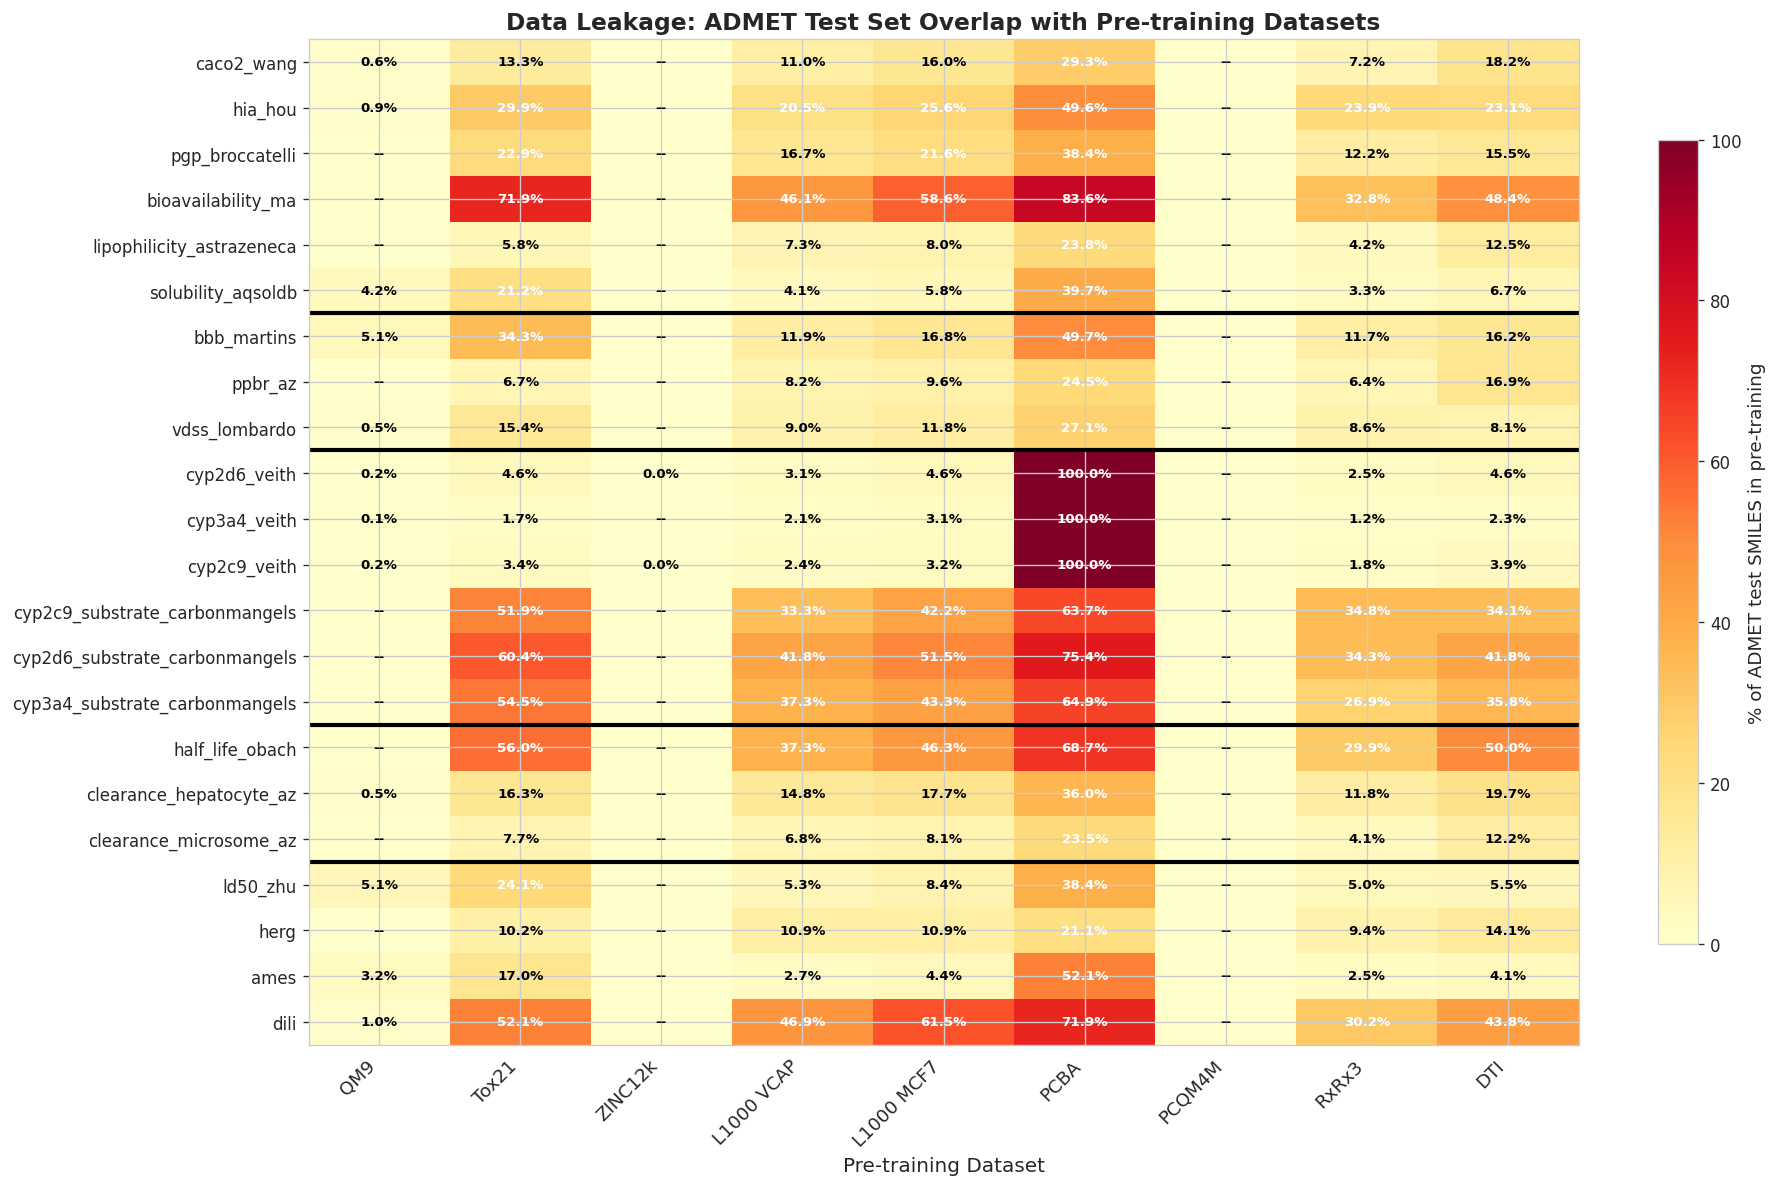


Max overlap: 100.0% (row=cyp2d6_veith, col=PCBA)


In [20]:
import matplotlib.pyplot as plt

# Build overlap matrix: pre-training dataset (cols) x ADMET task (rows)
# Use canonical ADMET_TASK_ORDER
pretrain_names = ['QM9', 'Tox21', 'ZINC12k', 'L1000 VCAP', 'L1000 MCF7',
                  'PCBA', 'PCQM4M', 'RxRx3', 'DTI']
task_names = [t for t in ADMET_TASK_ORDER if t in admet_test_smiles]

# Build y-tick labels with category prefix
CATEGORIES_ORDER = ['Absorption', 'Distribution', 'Metabolism', 'Excretion', 'Toxicity']
cat_short = {'Absorption': 'A', 'Distribution': 'D', 'Metabolism': 'M',
             'Excretion': 'E', 'Toxicity': 'T'}

matrix = np.zeros((len(task_names), len(pretrain_names)))
for i, task in enumerate(task_names):
    test_set = admet_test_smiles[task]
    for j, ds_name in enumerate(pretrain_names):
        ds = pretrain_datasets[ds_name]
        overlap = ds & test_set
        matrix[i, j] = 100 * len(overlap) / len(test_set) if test_set else 0

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0)

ax.set_xticks(range(len(pretrain_names)))
ax.set_xticklabels(pretrain_names, rotation=45, ha='right', fontsize=11)
ax.set_yticks(range(len(task_names)))
ax.set_yticklabels(task_names, fontsize=10)
ax.yaxis.set_ticks_position('left')

# Annotate cells with overlap %
for i in range(len(task_names)):
    for j in range(len(pretrain_names)):
        val = matrix[i, j]
        if val > 0:
            color = 'white' if val > 20 else 'black'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')
        else:
            ax.text(j, i, '--', ha='center', va='center',
                    fontsize=8, color='black', fontweight='bold')

# Draw thick lines between ADMET categories
prev_cat = None
for i, task in enumerate(task_names):
    cat = TASK_CATEGORY[task]
    if prev_cat is not None and cat != prev_cat:
        ax.axhline(y=i - 0.5, color='black', linewidth=2.5)
    prev_cat = cat

# Add category labels on the right
# for cat in CATEGORIES_ORDER:
#     indices = [i for i, t in enumerate(task_names) if TASK_CATEGORY.get(t) == cat]
#     if indices:
#         mid = (indices[0] + indices[-1]) / 2
#         ax.text(len(pretrain_names) + 0.3, mid, cat, ha='left', va='center',
#                 fontsize=10, fontweight='bold', color='#333')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('% of ADMET test SMILES in pre-training', fontsize=11)

ax.set_title('Data Leakage: ADMET Test Set Overlap with Pre-training Datasets',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Pre-training Dataset', fontsize=12)

plt.tight_layout()
plt.show()

if matrix.max() == 0:
    print('\nNo overlap detected — all clean!')
else:
    print(f'\nMax overlap: {matrix.max():.1f}% (row={task_names[matrix.max(axis=1).argmax()]}, '
          f'col={pretrain_names[matrix.max(axis=0).argmax()]})')

### 6. Summary

In [21]:
# Final summary
all_pretrain = set()
for ds_name in ['ToyMix (all)', 'LargeMix (all)', 'RxRx3', 'DTI']:
    all_pretrain |= pretrain_datasets[ds_name]

total_overlap = all_pretrain & admet_all_test
print(f'Total unique pre-training SMILES (all datasets): {len(all_pretrain):,}')
print(f'Total unique ADMET test SMILES (all tasks):      {len(admet_all_test):,}')
print(f'Overlap (SMILES in both):                        {len(total_overlap):,}')
print(f'  = {100*len(total_overlap)/len(admet_all_test):.1f}% of ADMET test')
print(f'  = {100*len(total_overlap)/len(all_pretrain):.4f}% of pre-training')

if total_overlap:
    print(f'\n⚠ WARNING: {len(total_overlap)} ADMET test SMILES found in pre-training data.')
    print('Overlapping SMILES (first 20):')
    for smi in sorted(total_overlap)[:20]:
        print(f'  {smi}')
else:
    print('\n✓ No data leakage detected.')

Total unique pre-training SMILES (all datasets): 5,227,880
Total unique ADMET test SMILES (all tasks):      13,818
Overlap (SMILES in both):                        9,358
  = 67.7% of ADMET test
  = 0.1790% of pre-training

⚠ WARNING: 9358 ADMET test SMILES found in pre-training data.
Overlapping SMILES (first 20):
  Br.CC(C)CC1CC(=O)OC1(C)C(=O)CSc1nc2ccccc2s1
  Br.CCCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2
  Br.CCCCCCN1Cc2ccccc2C1
  Br.CC[C@H]1CN2CC[C@@H]1C[C@H]2[C@@H](O)c1ccnc2ccc(OC)cc12.O
  Br.C[N+](C)(C)CCCCCNCC12CC3CC(CC(C3)C1)C2.[Br-]
  Br.N=C1c2ccccc2CN1NC(=O)c1ccc(Cl)cc1
  Br.N=C1c2ccccc2CN1NC(=O)c1ccc(F)cc1
  BrC(Br)Br
  BrC(c1cccc2ccccc12)c1cccc2ccccc12
  BrCC(Br)C1CCC(Br)C(Br)C1
  BrCC1CO1
  BrCc1c2ccccc2cc2ccccc12
  Brc1c(Br)c(Br)c(Oc2c(Br)c(Br)c(Br)c(Br)c2Br)c(Br)c1Br
  Brc1cc(Br)c(-c2c(Br)cc(Br)cc2Br)c(Br)c1
  Brc1ccc(-c2ccccc2)cc1
  Brc1ccc(-c2csc(N3CCC(c4ccccc4)C3)n2)cc1
  Brc1ccc(-c2nnc(-c3ccccc3)c(N3CCSCC3)n2)cc1
  Brc1ccc(CSc2nccn2-c2ccccc2)cc1
  Brc1ccc2ccccc2c1
  Brc1ccc2n

---
## 5. BBBC047 & LargeMix Overlap Analysis

In [22]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from rdkit import Chem

BBBC047_PATH = Path("/home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv")
ADMET_TEST_PATH = Path("/home/shpark/prj-molrepr/datacache/admet_smiles/admet_test_smiles.json")
ADMET_ALL_PATH = Path("/home/shpark/prj-molrepr/datacache/admet_smiles/admet_all_smiles.json")
ADMET_PER_TASK_PATH = Path("/home/shpark/prj-molrepr/datacache/admet_smiles/admet_smiles_per_task.json")

def canonicalize(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return smi
    return Chem.MolToSmiles(mol)

# Load BBBC047
bbbc_df = pd.read_csv(BBBC047_PATH, usecols=["SMILES"])
bbbc_df["SMILES_canon"] = bbbc_df["SMILES"].apply(canonicalize)
bbbc_smiles = set(bbbc_df["SMILES_canon"].tolist())

# Load ADMET SMILES
with open(ADMET_TEST_PATH) as f:
    admet_test = set(json.load(f))
with open(ADMET_ALL_PATH) as f:
    admet_all = set(json.load(f))
with open(ADMET_PER_TASK_PATH) as f:
    admet_per_task = json.load(f)

print(f"BBBC047 unique SMILES:   {len(bbbc_smiles):,}")
print(f"ADMET test SMILES:       {len(admet_test):,}")
print(f"ADMET all SMILES:        {len(admet_all):,}")

BBBC047 unique SMILES:   109,645
ADMET test SMILES:       13,818
ADMET all SMILES:        46,202


### Overall overlap

In [23]:
overlap_test = bbbc_smiles & admet_test
overlap_all = bbbc_smiles & admet_all

print(f"=== BBBC047 ↔ ADMET Overlap ===")
print(f"  BBBC047 ∩ ADMET test:  {len(overlap_test):,}  ({len(overlap_test)/len(bbbc_smiles)*100:.2f}% of BBBC047)")
print(f"  BBBC047 ∩ ADMET all:   {len(overlap_all):,}  ({len(overlap_all)/len(bbbc_smiles)*100:.2f}% of BBBC047)")
print(f"  ADMET test coverage:   {len(overlap_test)/len(admet_test)*100:.1f}% of ADMET test found in BBBC047")
print(f"  ADMET all coverage:    {len(overlap_all)/len(admet_all)*100:.1f}% of ADMET all found in BBBC047")

=== BBBC047 ↔ ADMET Overlap ===
  BBBC047 ∩ ADMET test:  974  (0.89% of BBBC047)
  BBBC047 ∩ ADMET all:   2,429  (2.22% of BBBC047)
  ADMET test coverage:   7.0% of ADMET test found in BBBC047
  ADMET all coverage:    5.3% of ADMET all found in BBBC047


### Per-task overlap breakdown

In [24]:
print(f"{'Task':<40} {'Test size':>10} {'Overlap':>10} {'%':>8}")
print("-" * 70)

task_overlaps = {}
for task, smi_dict in admet_per_task.items():
    test_smi = set(smi_dict["test"])
    overlap = bbbc_smiles & test_smi
    task_overlaps[task] = {"test_size": len(test_smi), "overlap": len(overlap)}
    pct = len(overlap) / len(test_smi) * 100 if test_smi else 0
    marker = " <<<" if len(overlap) > 0 else ""
    print(f"  {task:<38} {len(test_smi):>10,} {len(overlap):>10,} {pct:>7.1f}%{marker}")

total_overlap = sum(v["overlap"] for v in task_overlaps.values())
print(f"\n  {'TOTAL (sum across tasks)':<38} {sum(v['test_size'] for v in task_overlaps.values()):>10,} {total_overlap:>10,}")
print(f"  {'UNIQUE test SMILES in overlap':<38} {len(overlap_test):>10,}")

Task                                      Test size    Overlap        %
----------------------------------------------------------------------
  caco2_wang                                    181         21    11.6% <<<
  hia_hou                                       117         24    20.5% <<<
  pgp_broccatelli                               245         47    19.2% <<<
  bioavailability_ma                            128         37    28.9% <<<
  lipophilicity_astrazeneca                     840         48     5.7% <<<
  solubility_aqsoldb                          1,997        173     8.7% <<<
  bbb_martins                                   394         62    15.7% <<<
  ppbr_az                                       343         34     9.9% <<<
  vdss_lombardo                                 221         30    13.6% <<<
  cyp2d6_veith                                2,626        157     6.0% <<<
  cyp3a4_veith                                2,467        122     4.9% <<<
  cyp2c9_veith       

### Create filtered BBBC047 dataset (remove ADMET test SMILES)

In [25]:
# Load full BBBC047 dataset (all columns)
bbbc_full = pd.read_csv(BBBC047_PATH)
bbbc_full["SMILES_canon"] = bbbc_full["SMILES"].apply(canonicalize)

# Filter
mask_keep = ~bbbc_full["SMILES_canon"].isin(admet_test)
bbbc_filtered = bbbc_full[mask_keep].drop(columns=["SMILES_canon"]).reset_index(drop=True)

print(f"BBBC047 filtering:")
print(f"  Before:  {len(bbbc_full):,} compounds")
print(f"  Removed: {len(bbbc_full) - len(bbbc_filtered):,} (ADMET test overlap)")
print(f"  After:   {len(bbbc_filtered):,} compounds")

# Save
OUTPUT_PATH = Path("/home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings_filtered.csv")
bbbc_filtered.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved to: {OUTPUT_PATH}")
print(f"File size: {OUTPUT_PATH.stat().st_size / 1e6:.1f} MB")

# Verify
verify = pd.read_csv(OUTPUT_PATH, usecols=["SMILES"])
verify_canon = set(verify["SMILES"].apply(canonicalize).tolist())
leak = verify_canon & admet_test
print(f"\nVerification: {len(leak)} ADMET test SMILES remaining (should be 0)")
assert len(leak) == 0, f"Leakage: {len(leak)}"
print("PASS: No data leakage")

BBBC047 filtering:
  Before:  109,645 compounds
  Removed: 974 (ADMET test overlap)
  After:   108,671 compounds

Saved to: /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings_filtered.csv
File size: 744.8 MB

Verification: 0 ADMET test SMILES remaining (should be 0)
PASS: No data leakage


### Summary

In [26]:
print("=== Dataset Files ===")
print(f"  Original:  /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv")
print(f"             {len(bbbc_full):,} compounds, 672 dims")
print(f"  Filtered:  /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings_filtered.csv")
print(f"             {len(bbbc_filtered):,} compounds, 672 dims")
print(f"  Removed:   {len(bbbc_full) - len(bbbc_filtered):,} ADMET test SMILES")
print(f"\n=== Hydra configs ===")
print(f"  Original:  tasks=bbbc047  (uses bbbc047_smiles_embeddings.csv)")
print(f"  Filtered:  tasks=bbbc047_filtered  (needs new config pointing to _filtered.csv)")

=== Dataset Files ===
  Original:  /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv
             109,645 compounds, 672 dims
  Filtered:  /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings_filtered.csv
             108,671 compounds, 672 dims
  Removed:   974 ADMET test SMILES

=== Hydra configs ===
  Original:  tasks=bbbc047  (uses bbbc047_smiles_embeddings.csv)
  Filtered:  tasks=bbbc047_filtered  (needs new config pointing to _filtered.csv)


---

### LargeMix ↔ ADMET Overlap Check

Check overlap between each LargeMix pre-training dataset (L1000 VCAP, L1000 MCF7, PCBA 1328, PCQM4M) and the ADMET benchmark test sets.

In [27]:
LARGEMIX_DIR = Path("/home/shpark/prj-molrepr/graphium/data/graphium/neurips2023/large-dataset")

largemix_datasets = {
    "L1000_VCAP": {"path": LARGEMIX_DIR / "LINCS_L1000_VCAP_0-2_th2.csv.gz", "smiles_col": "SMILES"},
    "L1000_MCF7": {"path": LARGEMIX_DIR / "LINCS_L1000_MCF7_0-2_th2.csv.gz", "smiles_col": "SMILES"},
    "PCBA_1328":  {"path": LARGEMIX_DIR / "PCBA_1328_1564k.parquet",          "smiles_col": "SMILES"},
    "PCQM4M":     {"path": LARGEMIX_DIR / "PCQM4M_G25_N4.parquet",            "smiles_col": "ordered_smiles"},
}

# Load unique SMILES from each LargeMix dataset
largemix_smiles = {}
for name, info in largemix_datasets.items():
    p = info["path"]
    col = info["smiles_col"]
    if str(p).endswith(".parquet"):
        smi = pd.read_parquet(p, columns=[col])[col]
    else:
        smi = pd.read_csv(p, usecols=[col])[col]
    unique = set(smi.dropna().unique())
    largemix_smiles[name] = unique
    print(f"{name}: {len(unique):,} unique SMILES")

# Union of all LargeMix SMILES
all_largemix = set()
for s in largemix_smiles.values():
    all_largemix.update(s)
print(f"\nLargeMix total unique SMILES: {len(all_largemix):,}")

L1000_VCAP: 15,193 unique SMILES
L1000_MCF7: 11,585 unique SMILES
PCBA_1328: 1,563,664 unique SMILES
PCQM4M: 3,452,168 unique SMILES

LargeMix total unique SMILES: 5,033,096


### LargeMix ↔ ADMET test: overall overlap per dataset

In [28]:
print(f"{'Dataset':<20} {'Unique SMILES':>15} {'∩ ADMET test':>15} {'%':>8}")
print("-" * 62)

for name, smi_set in largemix_smiles.items():
    overlap = smi_set & admet_test
    pct = len(overlap) / len(smi_set) * 100 if smi_set else 0
    print(f"  {name:<18} {len(smi_set):>15,} {len(overlap):>15,} {pct:>7.2f}%")

all_overlap = all_largemix & admet_test
pct_all = len(all_overlap) / len(all_largemix) * 100
print("-" * 62)
print(f"  {'LargeMix (union)':<18} {len(all_largemix):>15,} {len(all_overlap):>15,} {pct_all:>7.2f}%")
print(f"\n  ADMET test coverage: {len(all_overlap)/len(admet_test)*100:.1f}% of ADMET test SMILES found in LargeMix")

Dataset                Unique SMILES    ∩ ADMET test        %
--------------------------------------------------------------
  L1000_VCAP                  15,193             164    1.08%
  L1000_MCF7                  11,585             231    1.99%
  PCBA_1328                1,563,664           8,834    0.56%
  PCQM4M                   3,452,168               0    0.00%
--------------------------------------------------------------
  LargeMix (union)         5,033,096           8,848    0.18%

  ADMET test coverage: 64.0% of ADMET test SMILES found in LargeMix


### LargeMix ↔ ADMET test: per-task breakdown

Show overlap between the LargeMix union and each of the 22 ADMET benchmark test sets.

In [29]:
print(f"{'Task':<40} {'Test size':>10} {'∩ LargeMix':>12} {'%':>8}")
print("-" * 74)

lm_task_overlaps = {}
for task, smi_dict in admet_per_task.items():
    test_smi = set(smi_dict["test"])
    overlap = all_largemix & test_smi
    lm_task_overlaps[task] = {"test_size": len(test_smi), "overlap": len(overlap)}
    pct = len(overlap) / len(test_smi) * 100 if test_smi else 0
    marker = " <<<" if len(overlap) > 0 else ""
    print(f"  {task:<38} {len(test_smi):>10,} {len(overlap):>10,} {pct:>7.1f}%{marker}")

total_overlap_lm = sum(v["overlap"] for v in lm_task_overlaps.values())
total_test = sum(v["test_size"] for v in lm_task_overlaps.values())
print(f"\n  {'TOTAL (sum across tasks)':<38} {total_test:>10,} {total_overlap_lm:>10,}")
print(f"  {'UNIQUE test SMILES in overlap':<38} {len(all_overlap):>10,}")

Task                                      Test size   ∩ LargeMix        %
--------------------------------------------------------------------------
  caco2_wang                                    181         50    27.6% <<<
  hia_hou                                       117         58    49.6% <<<
  pgp_broccatelli                               245         92    37.6% <<<
  bioavailability_ma                            128        104    81.2% <<<
  lipophilicity_astrazeneca                     840        198    23.6% <<<
  solubility_aqsoldb                          1,997        779    39.0% <<<
  bbb_martins                                   394        189    48.0% <<<
  ppbr_az                                       343         85    24.8% <<<
  vdss_lombardo                                 221         60    27.1% <<<
  cyp2d6_veith                                2,626      2,557    97.4% <<<
  cyp3a4_veith                                2,467      2,390    96.9% <<<
  cyp2c9_veith 

### Per-dataset contribution to overlap

Which LargeMix dataset contributes most to the ADMET test leakage?

In [30]:
print(f"{'Dataset':<20} {'∩ ADMET test':>15} {'% of ADMET test':>18} {'Exclusive':>12}")
print("-" * 68)

# Find which datasets exclusively contribute overlap SMILES
for name, smi_set in largemix_smiles.items():
    overlap = smi_set & admet_test
    # Exclusive = in this dataset's overlap but not in any other dataset
    others = set()
    for other_name, other_set in largemix_smiles.items():
        if other_name != name:
            others.update(other_set & admet_test)
    exclusive = overlap - others
    pct = len(overlap) / len(admet_test) * 100
    print(f"  {name:<18} {len(overlap):>15,} {pct:>17.1f}% {len(exclusive):>12,}")

print(f"\n  {'LargeMix (union)':<18} {len(all_overlap):>15,} {len(all_overlap)/len(admet_test)*100:>17.1f}%")

Dataset                 ∩ ADMET test    % of ADMET test    Exclusive
--------------------------------------------------------------------
  L1000_VCAP                     164               1.2%            1
  L1000_MCF7                     231               1.7%            5
  PCBA_1328                    8,834              63.9%        8,615
  PCQM4M                           0               0.0%            0

  LargeMix (union)             8,848              64.0%


### Comparison: all pre-training datasets vs ADMET test

In [31]:
# Load DTI and ToyMix SMILES for a complete picture
TOYMIX_DIR = Path("/home/shpark/prj-molrepr/graphium/data/graphium/neurips2023/small-dataset")
DTI_DIR = Path("/home/shpark/prj-molrepr/graphium/data/dti-processed")

extra_datasets = {
    "ToyMix (QM9)":     {"path": TOYMIX_DIR / "qm9.csv", "smiles_col": "smiles"},
    "ToyMix (Tox21)":   {"path": TOYMIX_DIR / "Tox21-7k-12-labels.csv", "smiles_col": "smiles"},
    "ToyMix (ZINC12k)": {"path": TOYMIX_DIR / "ZINC12k.csv", "smiles_col": "smiles"},
    "DTI 10K":          {"path": DTI_DIR / "dti_esm2_10k.csv", "smiles_col": "SMILES_nometa"},
    "DTI 100K":         {"path": DTI_DIR / "dti_esm2_100k.csv", "smiles_col": "SMILES_nometa"},
    "BBBC047":          {"path": BBBC047_PATH, "smiles_col": "SMILES"},
}

print(f"{'Dataset':<20} {'Unique SMILES':>15} {'∩ ADMET test':>15} {'% of dataset':>14} {'% of ADMET test':>17}")
print("-" * 85)

for name, info in {**{k: {"smiles": v} for k, v in largemix_smiles.items()}, }.items():
    smi_set = info["smiles"]
    overlap = smi_set & admet_test
    pct_ds = len(overlap) / len(smi_set) * 100 if smi_set else 0
    pct_admet = len(overlap) / len(admet_test) * 100
    print(f"  {name:<18} {len(smi_set):>15,} {len(overlap):>15,} {pct_ds:>13.2f}% {pct_admet:>16.1f}%")

for name, info in extra_datasets.items():
    p = info["path"]
    col = info["smiles_col"]
    if str(p).endswith(".parquet"):
        smi = pd.read_parquet(p, columns=[col])[col]
    else:
        smi = pd.read_csv(p, usecols=[col])[col]
    smi_set = set(smi.dropna().unique())
    overlap = smi_set & admet_test
    pct_ds = len(overlap) / len(smi_set) * 100 if smi_set else 0
    pct_admet = len(overlap) / len(admet_test) * 100
    print(f"  {name:<18} {len(smi_set):>15,} {len(overlap):>15,} {pct_ds:>13.2f}% {pct_admet:>16.1f}%")

Dataset                Unique SMILES    ∩ ADMET test   % of dataset   % of ADMET test
-------------------------------------------------------------------------------------
  L1000_VCAP                  15,193             164          1.08%              1.2%
  L1000_MCF7                  11,585             231          1.99%              1.7%
  PCBA_1328                1,563,664           8,834          0.56%             63.9%
  PCQM4M                   3,452,168               0          0.00%              0.0%
  ToyMix (QM9)               133,802             112          0.08%              0.8%
  ToyMix (Tox21)               7,831           1,400         17.88%             10.1%
  ToyMix (ZINC12k)            12,000               2          0.02%              0.0%
  DTI 10K                      8,630             190          2.20%              1.4%
  DTI 100K                    72,183             824          1.14%              6.0%
  BBBC047                    109,645             974  

### Visualization: Pre-training Dataset ↔ ADMET Test Overlap

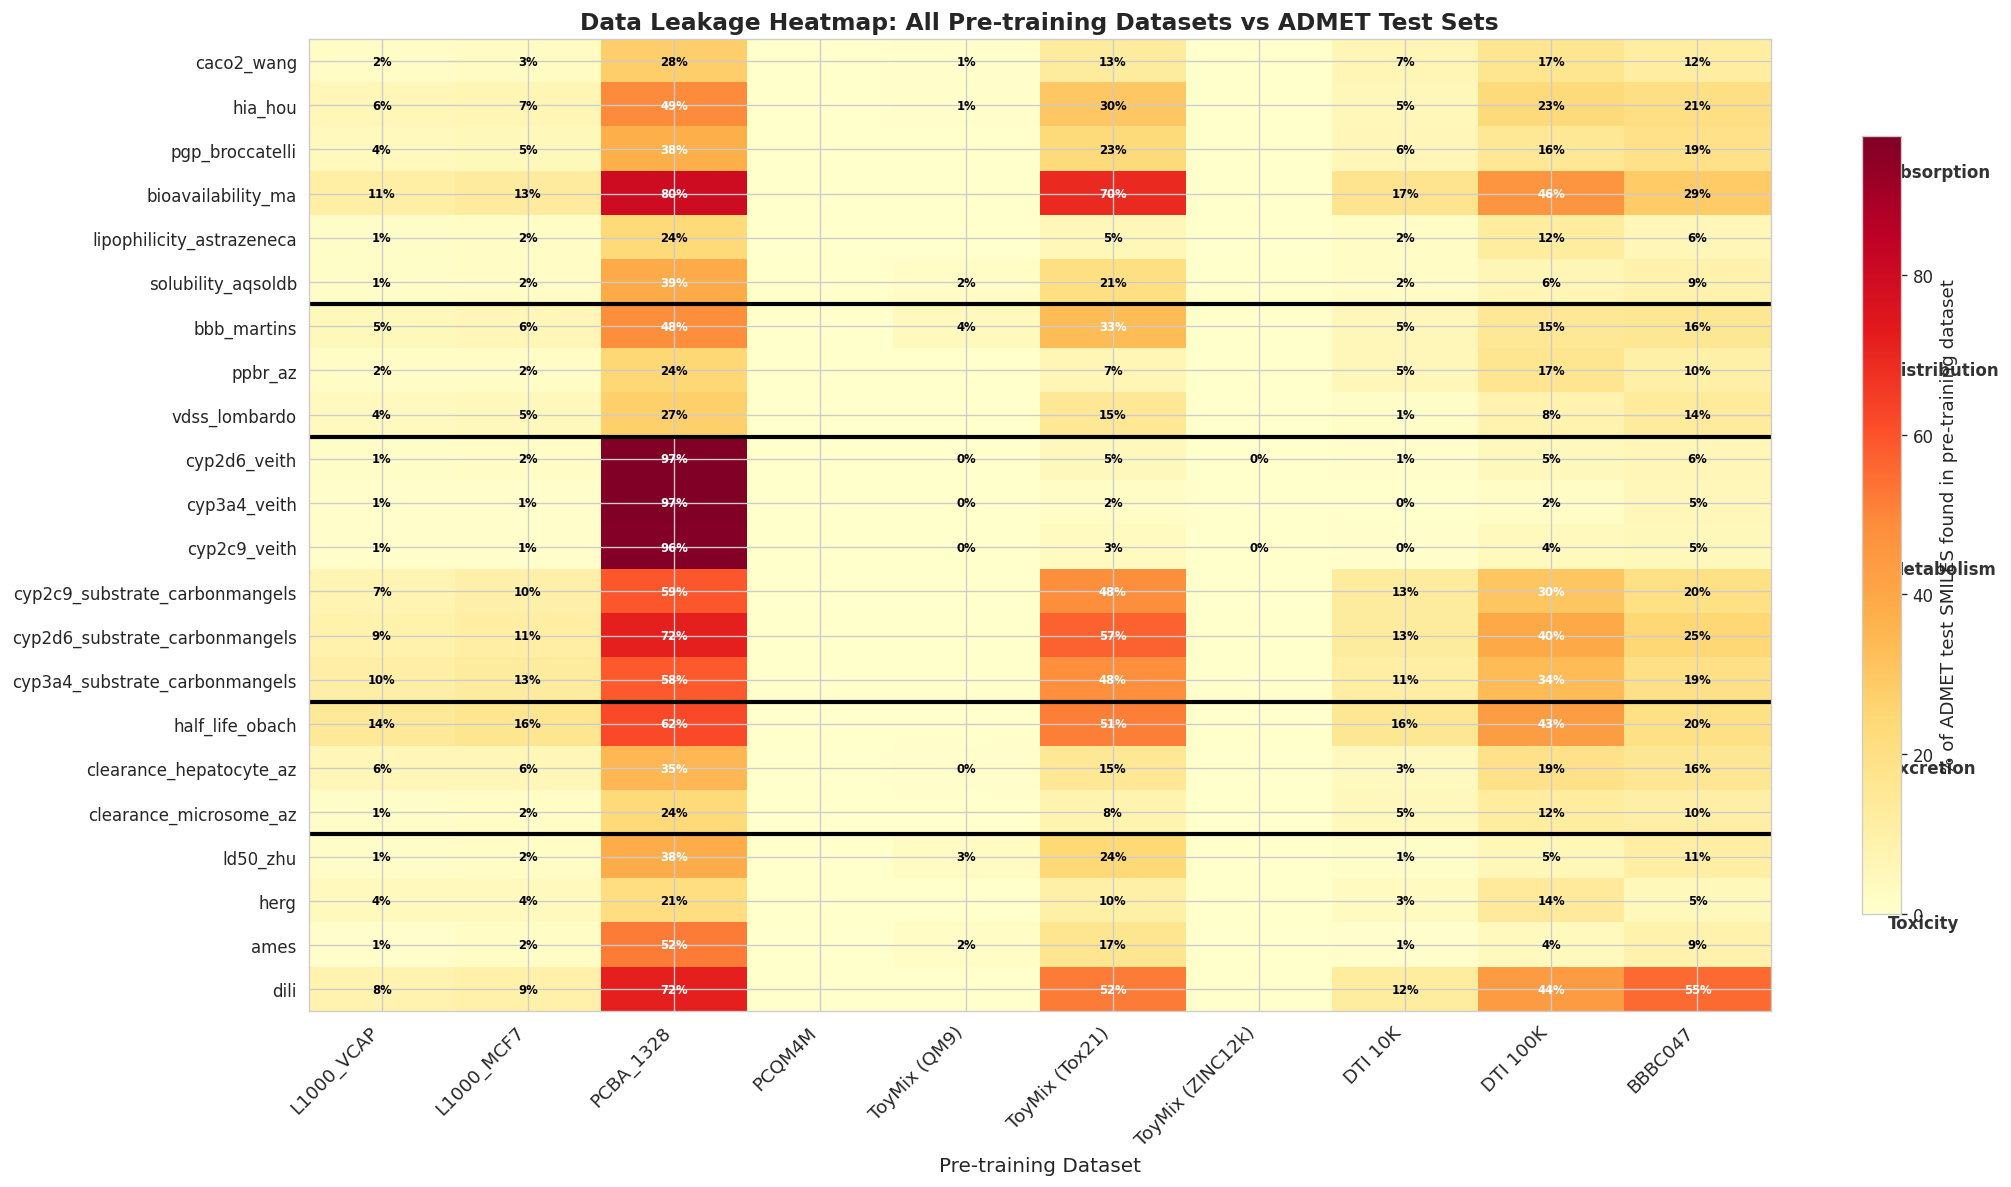

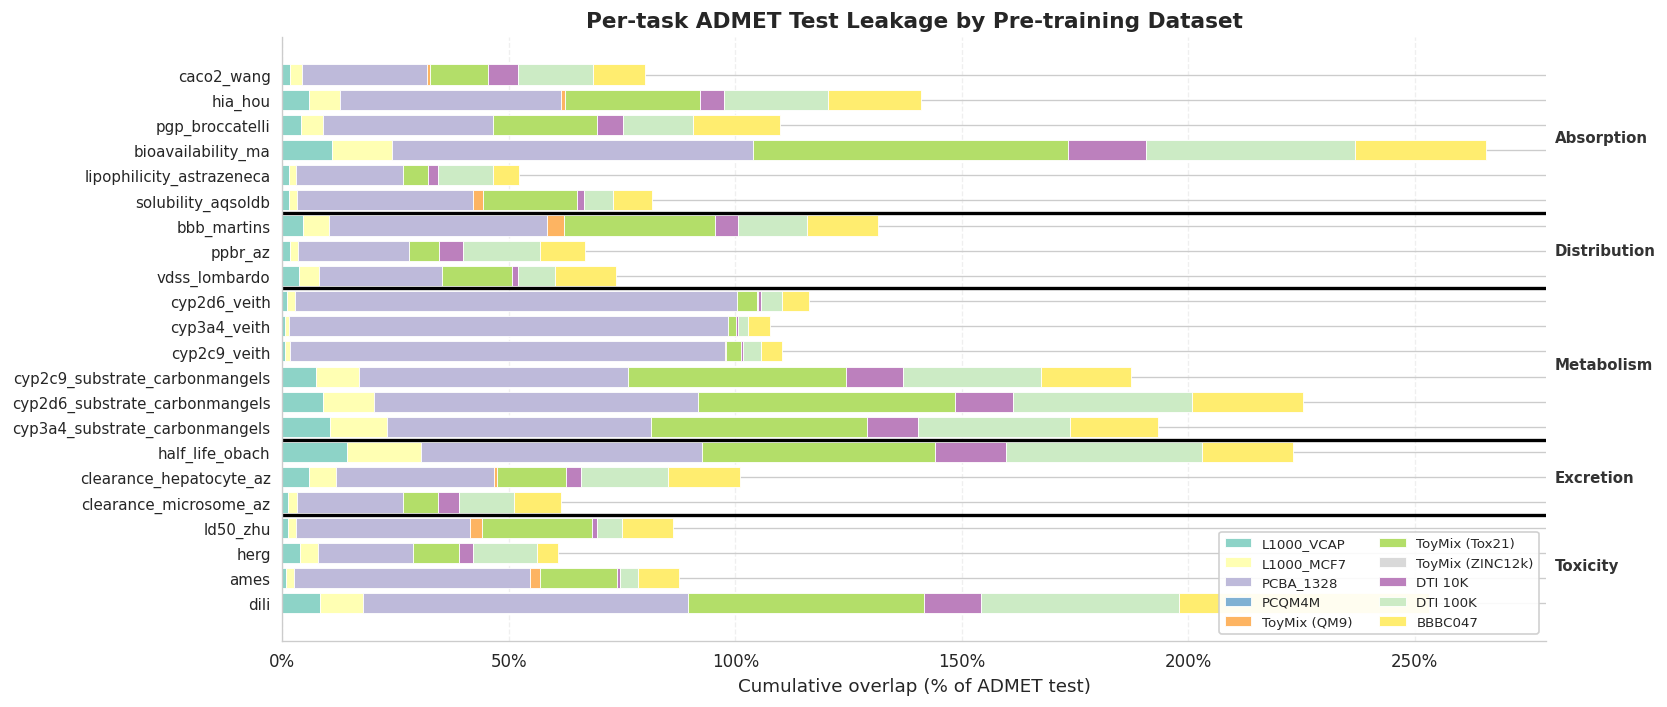

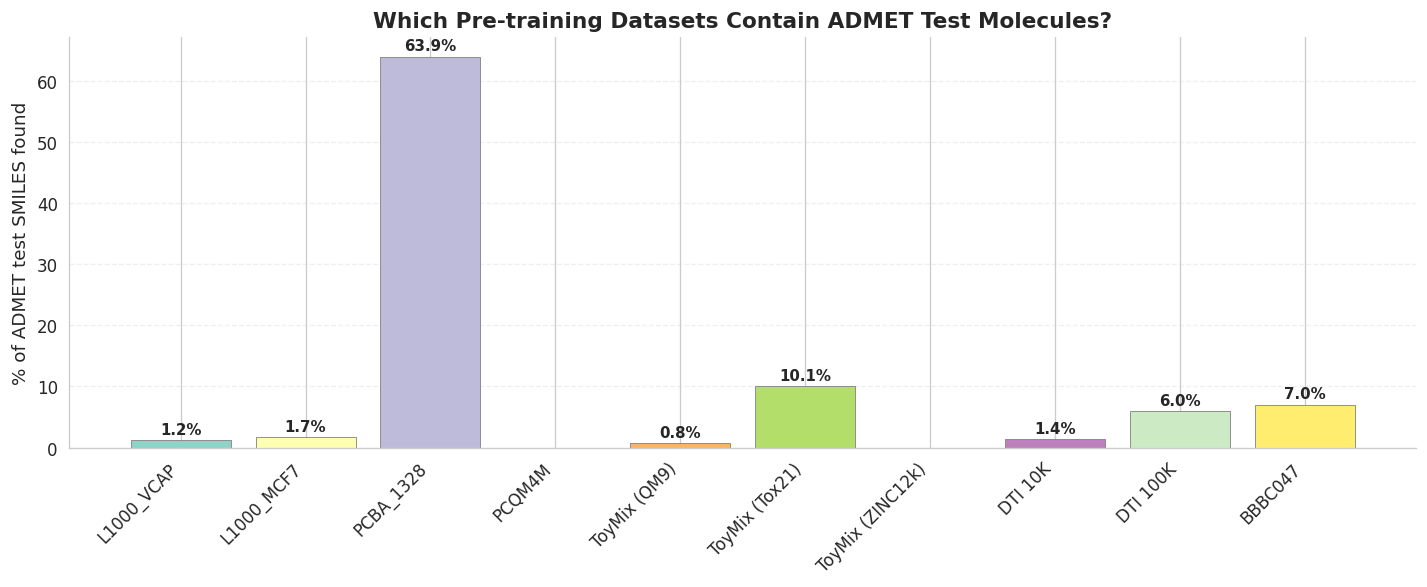


Worst offenders: PCBA (64%), Tox21 (10%), BBBC047 (7%), DTI 100K (6%)
Clean datasets: PCQM4M (0%), ZINC12k (0%)


In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Canonical ADMET task ordering (A -> D -> M -> E -> T)
ADMET_TASK_ORDER = [
    'caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
    'lipophilicity_astrazeneca', 'solubility_aqsoldb',
    'bbb_martins', 'ppbr_az', 'vdss_lombardo',
    'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith',
    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels',
    'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az',
    'ld50_zhu', 'herg', 'ames', 'dili',
]
CATEGORY_BOUNDS = {'Absorption': (0, 6), 'Distribution': (6, 9), 'Metabolism': (9, 15),
                   'Excretion': (15, 18), 'Toxicity': (18, 22)}

# Collect all pre-training dataset SMILES sets
all_pretrain = {}
for name, smi_set in largemix_smiles.items():
    all_pretrain[name] = smi_set
for name, info in extra_datasets.items():
    p = info["path"]
    col = info["smiles_col"]
    if str(p).endswith(".parquet"):
        smi = pd.read_parquet(p, columns=[col])[col]
    else:
        smi = pd.read_csv(p, usecols=[col])[col]
    all_pretrain[name] = set(smi.dropna().unique())

pretrain_names = list(all_pretrain.keys())
task_names = [t for t in ADMET_TASK_ORDER if t in admet_per_task]

# Build overlap matrix (% of ADMET test found in each pretrain dataset)
matrix = np.zeros((len(task_names), len(pretrain_names)))
for i, task in enumerate(task_names):
    test_smi = set(admet_per_task[task]["test"])
    for j, ds_name in enumerate(pretrain_names):
        overlap = all_pretrain[ds_name] & test_smi
        matrix[i, j] = 100 * len(overlap) / len(test_smi) if test_smi else 0

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(18, 10))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0)

ax.set_xticks(range(len(pretrain_names)))
ax.set_xticklabels(pretrain_names, rotation=45, ha='right', fontsize=11)
ax.set_yticks(range(len(task_names)))
ax.set_yticklabels(task_names, fontsize=10)

# Annotate
for i in range(len(task_names)):
    for j in range(len(pretrain_names)):
        val = matrix[i, j]
        if val > 0:
            color = 'white' if val > 30 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7, color=color, fontweight='bold')

# Category separators
for cat, (start, end) in CATEGORY_BOUNDS.items():
    if start > 0:
        ax.axhline(y=start - 0.5, color='black', linewidth=2.5)
    mid = (start + end - 1) / 2
    ax.text(len(pretrain_names) + 0.3, mid, cat, ha='left', va='center',
            fontsize=10, fontweight='bold', color='#333')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('% of ADMET test SMILES found in pre-training dataset', fontsize=11)

ax.set_title('Data Leakage Heatmap: All Pre-training Datasets vs ADMET Test Sets',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Pre-training Dataset', fontsize=12)
plt.tight_layout()
plt.show()

# --- Stacked bar chart: per-task total overlap across datasets ---
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(task_names))
ds_colors = plt.cm.Set3(np.linspace(0, 1, len(pretrain_names)))

for j, (ds_name, color) in enumerate(zip(pretrain_names, ds_colors)):
    vals = matrix[:, j]
    ax.barh(range(len(task_names)), vals, left=bottom, color=color,
            edgecolor='white', linewidth=0.5, label=ds_name, height=0.8)
    bottom += vals

ax.set_yticks(range(len(task_names)))
ax.set_yticklabels(task_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Cumulative overlap (% of ADMET test)', fontsize=11)
ax.set_title('Per-task ADMET Test Leakage by Pre-training Dataset', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Category separators
for cat, (start, end) in CATEGORY_BOUNDS.items():
    if start > 0:
        ax.axhline(y=start - 0.5, color='black', linewidth=2)
    mid = (start + end - 1) / 2
    ax.text(ax.get_xlim()[1] + 2, mid, cat, ha='left', va='center',
            fontsize=9, fontweight='bold', color='#333', clip_on=False)

ax.legend(loc='lower right', fontsize=8, ncol=2, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Summary bar: dataset-level overlap with ADMET test ---
fig, ax = plt.subplots(figsize=(12, 5))
ds_overlap_pcts = []
for ds_name in pretrain_names:
    overlap = all_pretrain[ds_name] & admet_test
    ds_overlap_pcts.append(len(overlap) / len(admet_test) * 100)

bars = ax.bar(range(len(pretrain_names)), ds_overlap_pcts, color=ds_colors,
              edgecolor='grey', linewidth=0.5)

# Annotate bars
for i, (bar, pct) in enumerate(zip(bars, ds_overlap_pcts)):
    if pct > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(pretrain_names)))
ax.set_xticklabels(pretrain_names, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('% of ADMET test SMILES found', fontsize=11)
ax.set_title('Which Pre-training Datasets Contain ADMET Test Molecules?',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nWorst offenders: PCBA (64%), Tox21 (10%), BBBC047 (7%), DTI 100K (6%)")
print(f"Clean datasets: PCQM4M (0%), ZINC12k (0%)")